# Persona Demographic Bias Analysis
Tests for unintentional associations between demographic variables in the 500-persona pool.


In [39]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path("..").resolve()))

PERSONA_DIR = Path("../data/output/craft_persona_20260501_184525")

rows = []
for fp in sorted(PERSONA_DIR.glob("experiment_*.json")):
    try:
        with open(fp, encoding="utf-8") as f:
            data = json.load(f)
        demo = data.get("demographics", {})
        demo["persona_id"] = data.get("persona_id")
        rows.append(demo)
    except Exception:
        pass

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} personas")
print(df.dtypes)
df.head(3)

Loaded 500 personas
age                     int64
gender                 object
ethnicity              object
relationship_status    object
occupation             object
trauma_type            object
pcl5                    int64
persona_id              int64
dtype: object


,age,gender,ethnicity,relationship_status,occupation,trauma_type,pcl5,persona_id
0,58,Male,South Asian,Married,Bomb Disposal Technician,Child's life-threatening illness,39,1
1,30,Female,Oceania,Married,Plumber,Physical abuse by caregiver (childhood),34,10
2,39,Male,Oceania,Divorced,Airline Pilot,Police,79,100


## 1. Demographic distributions of the 500 personas

In [40]:
cat_cols = ['gender', 'ethnicity', 'trauma_type', 'relationship_status']

for col in cat_cols:
    counts = df[col].value_counts()
    pct    = (counts / len(df) * 100).round(1)
    tbl    = pd.DataFrame({'n': counts, '%': pct})
    print(f"\n{'='*45}")
    print(f"  {col.upper().replace('_',' ')}  (n={len(df)})")
    print(f"{'='*45}")
    print(tbl.to_string())

print(f"\n{'='*45}")
print(f"  AGE  (n={len(df)})")
print(f"{'='*45}")
print(df['age'].describe().round(1).to_string())

print(f"\n{'='*45}")
print(f"  PCL-5  (n={len(df)})")
print(f"{'='*45}")
print(df['pcl5'].describe().round(1).to_string())



  GENDER  (n=500)
              n     %
gender               
Male        258  51.6
Female      238  47.6
Non-binary    4   0.8

  ETHNICITY  (n=500)
                      n     %
ethnicity                    
South Eastern Asian  71  14.2
European             70  14.0
North American       68  13.6
African              62  12.4
South Asian          60  12.0
Latin American       59  11.8
Oceania              57  11.4
Middle Eastern       53  10.6

  TRAUMA TYPE  (n=500)
                                                n    %
trauma_type                                           
Physical abuse by romantic partner             28  5.6
Accidentally caused serious injury to another  23  4.6
Assault                                        23  4.6
Civilian in war zone                           23  4.6
Physical abuse by caregiver (childhood)        23  4.6
Trauma to a loved one                          22  4.4
Terrorism                                      20  4.0
Torture                       

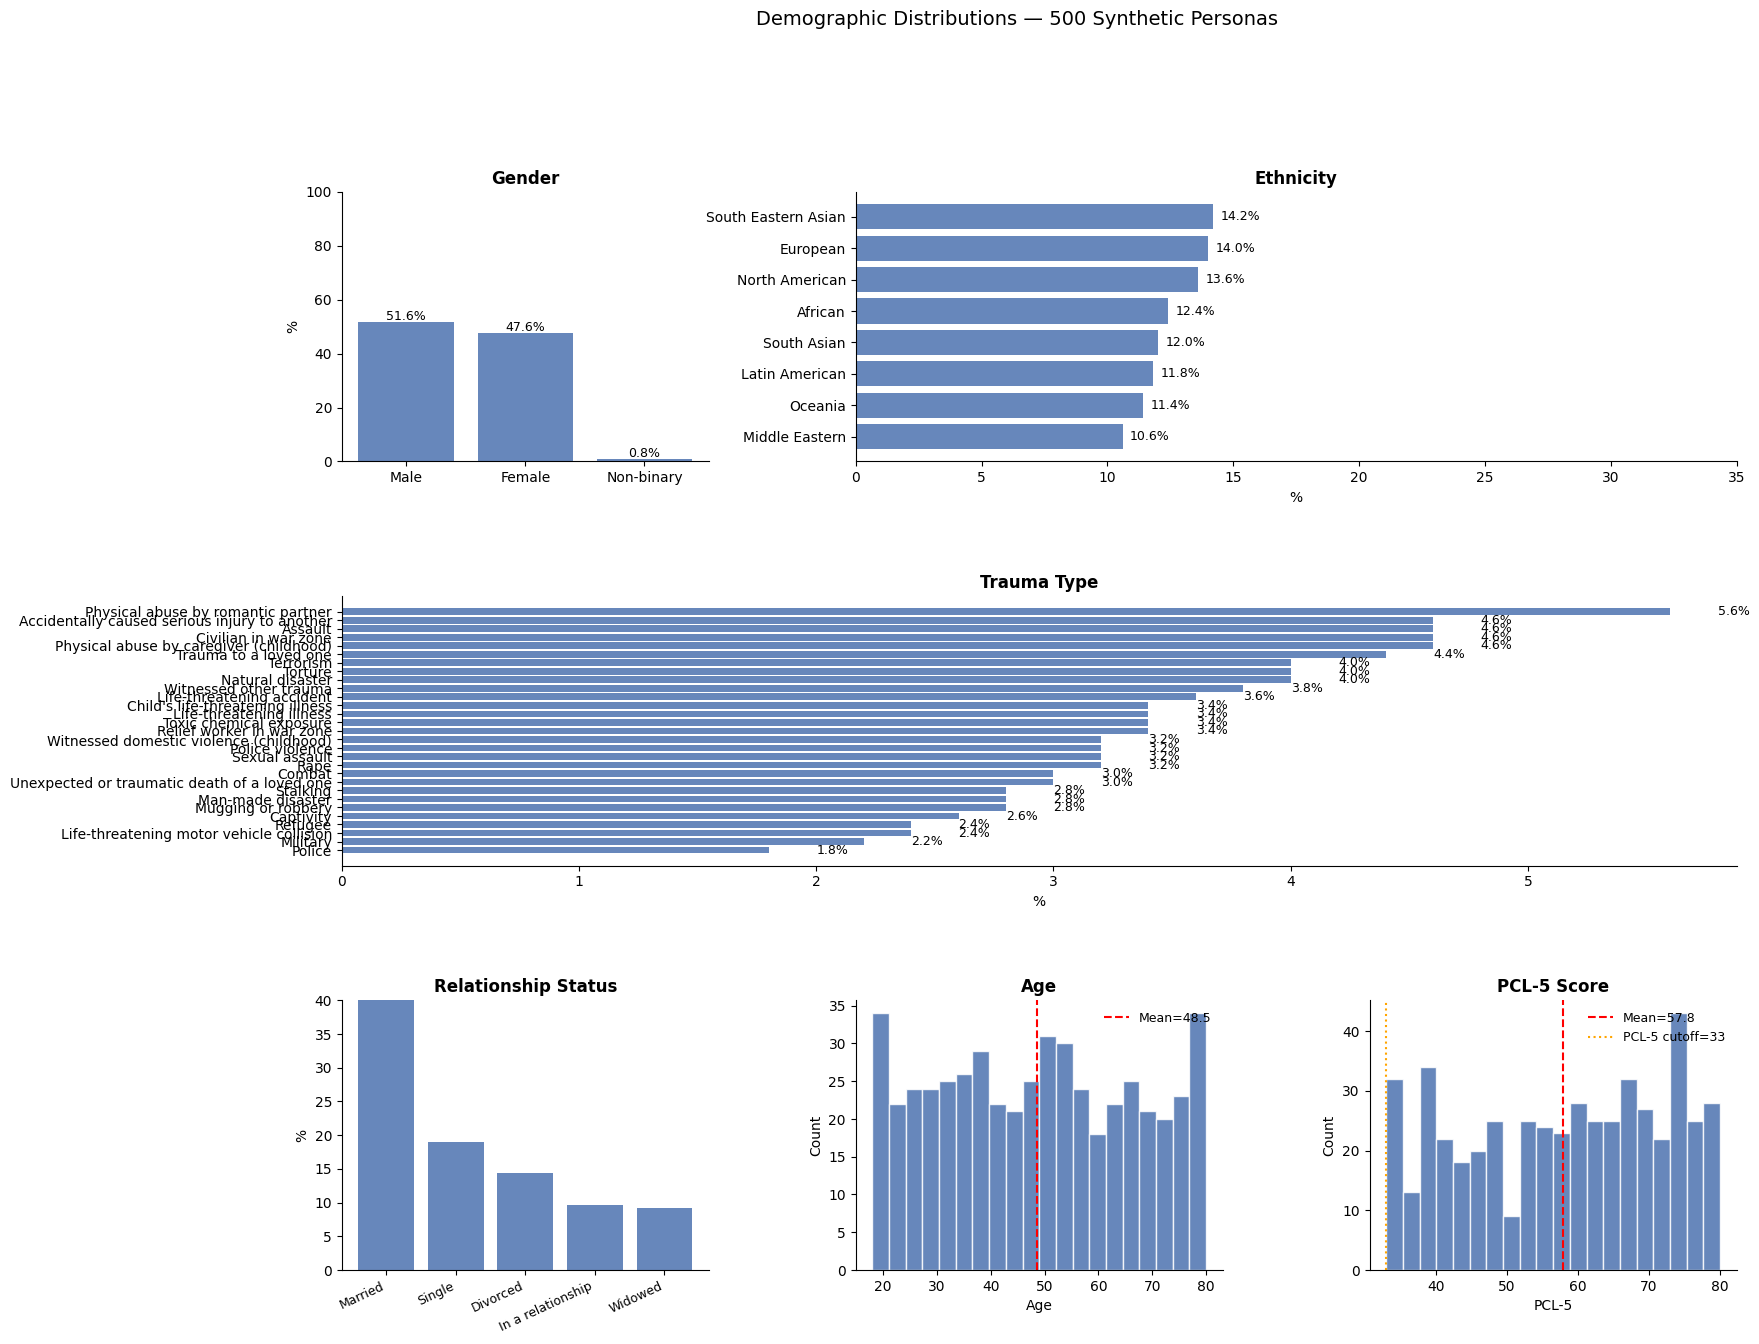

Saved -> data/analysis/persona_demographics.png


In [41]:
fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.4)

BLUE = '#4C72B0'

# Gender
ax = fig.add_subplot(gs[0, 0])
s = df['gender'].value_counts()
ax.bar(s.index, s.values / len(df) * 100, color=BLUE, alpha=0.85)
ax.set_title('Gender', fontsize=12, fontweight='bold')
ax.set_ylabel('%'); ax.set_ylim(0, 100)
ax.spines[['top','right']].set_visible(False)
for i, v in enumerate(s.values):
    ax.text(i, v/len(df)*100 + 1, f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)

# Ethnicity
ax = fig.add_subplot(gs[0, 1:])
s = df['ethnicity'].value_counts()
ax.barh(s.index[::-1], s.values[::-1] / len(df) * 100, color=BLUE, alpha=0.85)
ax.set_title('Ethnicity', fontsize=12, fontweight='bold')
ax.set_xlabel('%'); ax.set_xlim(0, 35)
ax.spines[['top','right']].set_visible(False)
for i, v in enumerate(s.values[::-1]):
    ax.text(v/len(df)*100 + 0.3, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=9)

# Trauma type
ax = fig.add_subplot(gs[1, :])
s = df['trauma_type'].value_counts()
ax.barh(s.index[::-1], s.values[::-1] / len(df) * 100, color=BLUE, alpha=0.85)
ax.set_title('Trauma Type', fontsize=12, fontweight='bold')
ax.set_xlabel('%')
ax.spines[['top','right']].set_visible(False)
for i, v in enumerate(s.values[::-1]):
    ax.text(v/len(df)*100 + 0.2, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=9)

# Relationship status
ax = fig.add_subplot(gs[2, 0])
s = df['relationship_status'].value_counts()
ax.bar(range(len(s)), s.values / len(df) * 100, color=BLUE, alpha=0.85)
ax.set_xticks(range(len(s)))
ax.set_xticklabels(s.index, rotation=25, ha='right', fontsize=9)
ax.set_title('Relationship Status', fontsize=12, fontweight='bold')
ax.set_ylabel('%'); ax.set_ylim(0, 40)
ax.spines[['top','right']].set_visible(False)

# Age distribution
ax = fig.add_subplot(gs[2, 1])
ax.hist(df['age'], bins=20, color=BLUE, alpha=0.85, edgecolor='white')
ax.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean={df['age'].mean():.1f}")
ax.set_title('Age', fontsize=12, fontweight='bold')
ax.set_xlabel('Age'); ax.set_ylabel('Count')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top','right']].set_visible(False)

# PCL-5 distribution
ax = fig.add_subplot(gs[2, 2])
ax.hist(df['pcl5'], bins=20, color=BLUE, alpha=0.85, edgecolor='white')
ax.axvline(df['pcl5'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean={df['pcl5'].mean():.1f}")
ax.axvline(33, color='orange', linestyle=':', linewidth=1.5, label='PCL-5 cutoff=33')
ax.set_title('PCL-5 Score', fontsize=12, fontweight='bold')
ax.set_xlabel('PCL-5'); ax.set_ylabel('Count')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Demographic Distributions — 500 Synthetic Personas', fontsize=14, y=1.01)
plt.savefig('../data/analysis/persona_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> data/analysis/persona_demographics.png')


## 2. Streamlit-style demographics charts
Replicates the color scheme and layout from `streamlit_app/pages/6_Demographics.py`.

In [42]:
import sys as _sys
import matplotlib as mpl
if str(Path('..').resolve()) not in _sys.path:
    _sys.path.insert(0, str(Path('..').resolve()))

from configs.demographics import OCCUPATION_GROUPS

C_AGE    = '#8CBBED'
C_PCL5   = '#FA9F9F'
C_RS     = '#72B7B2'
C_ETH    = '#FACA7E'
C_TRAUMA = '#D4C1F8'
C_OCC    = '#76C87E'
SET2     = mpl.colormaps['Set2'].colors

df['occupation_group'] = df['occupation'].map(OCCUPATION_GROUPS).fillna('Other')
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)


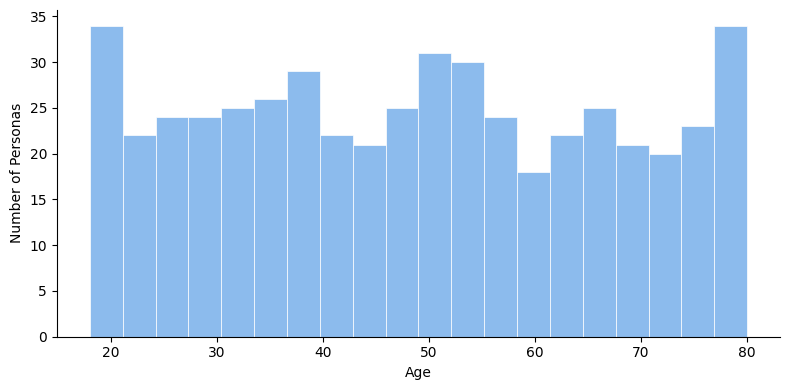

In [43]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['age'].dropna(), bins=20, color=C_AGE, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Age'); ax.set_ylabel('Number of Personas')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "plot_age.pdf", bbox_inches="tight", format="pdf")
plt.show()

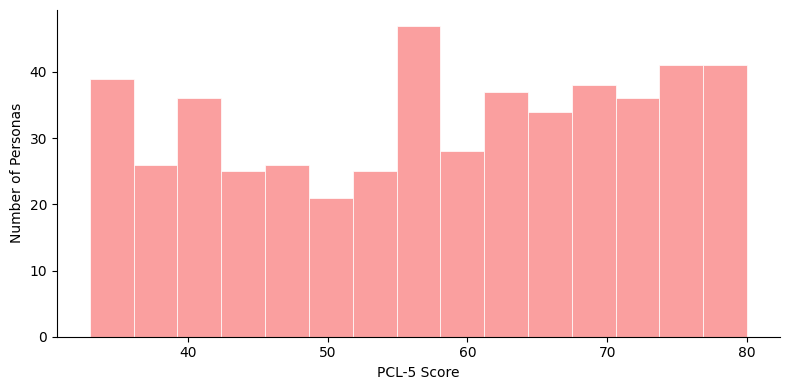

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['pcl5'].dropna(), bins=15, color=C_PCL5, edgecolor='white', linewidth=0.5)
ax.set_xlabel('PCL-5 Score'); ax.set_ylabel('Number of Personas')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "plot_pcl5.pdf", bbox_inches="tight", format="pdf")
plt.show()

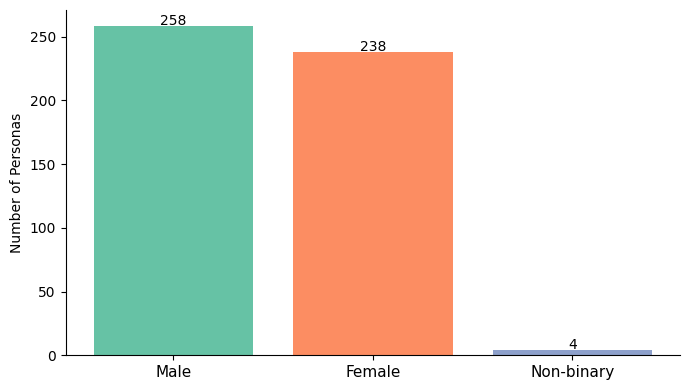

In [45]:
fig, ax = plt.subplots(figsize=(7, 4))
s = df['gender'].value_counts()
bars = ax.bar(range(len(s)), s.values, color=[SET2[i % len(SET2)] for i in range(len(s))])
ax.set_xticks(range(len(s))); ax.set_xticklabels(s.index, fontsize=11)
ax.set_ylabel('Number of Personas')
ax.spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars, s.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center', fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "plot_gender.pdf", bbox_inches="tight", format="pdf")
plt.show()

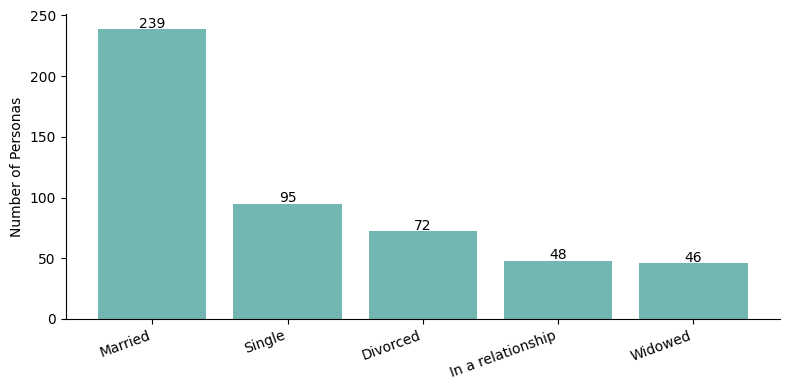

In [46]:
fig, ax = plt.subplots(figsize=(8, 4))
s = df['relationship_status'].value_counts()
bars = ax.bar(range(len(s)), s.values, color=C_RS)
ax.set_xticks(range(len(s))); ax.set_xticklabels(s.index, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Number of Personas')
ax.spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars, s.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center', fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "plot_relationship_status.pdf", bbox_inches="tight", format="pdf")
plt.show()

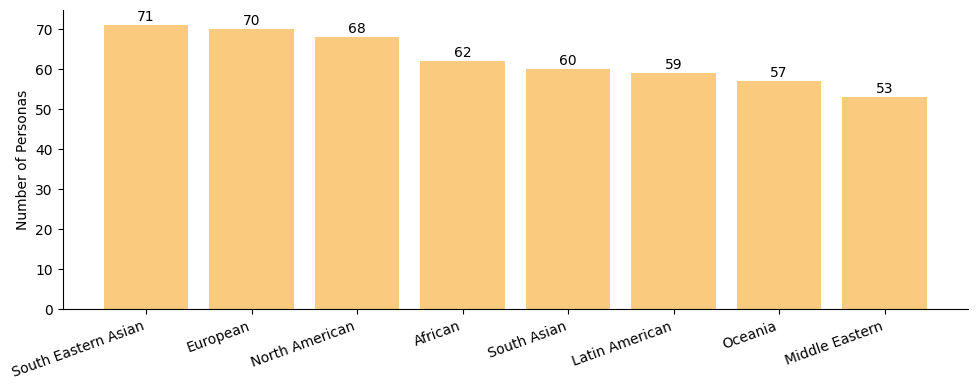

In [47]:
fig, ax = plt.subplots(figsize=(10, 4))
s = df['ethnicity'].value_counts()
bars = ax.bar(range(len(s)), s.values, color=C_ETH)
ax.set_xticks(range(len(s))); ax.set_xticklabels(s.index, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Number of Personas')
ax.spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars, s.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center', fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "plot_ethnicity.pdf", bbox_inches="tight", format="pdf")
plt.show()

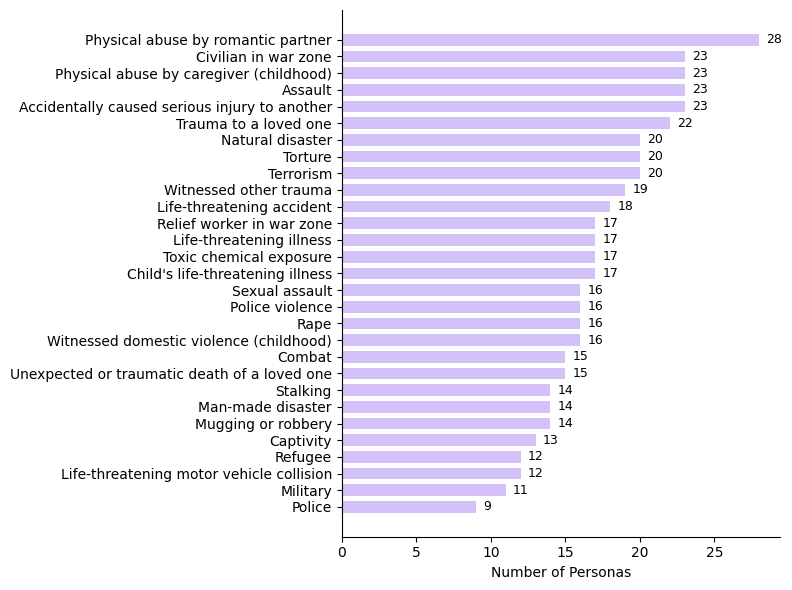

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))
s = df['trauma_type'].value_counts().sort_values()
y = range(len(s))
ax.barh(y, s.values, height=0.7, color=C_TRAUMA)
ax.set_yticks(y); ax.set_yticklabels(s.index, fontsize=10)
ax.set_xlabel('Number of Personas')
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(s.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "plot_trauma_type.pdf", bbox_inches="tight", format="pdf")
plt.show()

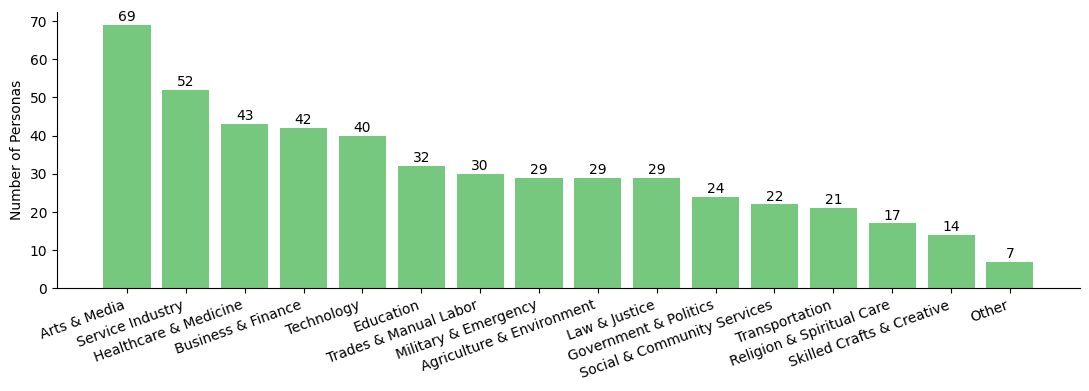

In [49]:
fig, ax = plt.subplots(figsize=(11, 4))
s = df['occupation_group'].value_counts()
bars = ax.bar(range(len(s)), s.values, color=C_OCC)
ax.set_xticks(range(len(s))); ax.set_xticklabels(s.index, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Number of Personas')
ax.spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars, s.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center', fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "plot_occupation.pdf", bbox_inches="tight", format="pdf")
plt.show()

In [50]:
# occupation_group already set from OCCUPATION_GROUPS mapping in the setup cell above

# Age bins
df["age_bin"] = pd.cut(df["age"], bins=[17, 30, 42, 54, 66, 80],
                        labels=["18-30", "31-42", "43-54", "55-66", "67-80"])

print("Occupation groups:", df["occupation_group"].value_counts().to_dict())
print("Age bins:         ", df["age_bin"].value_counts().sort_index().to_dict())

Occupation groups: {'Arts & Media': 69, 'Service Industry': 52, 'Healthcare & Medicine': 43, 'Business & Finance': 42, 'Technology': 40, 'Education': 32, 'Trades & Manual Labor': 30, 'Military & Emergency': 29, 'Agriculture & Environment': 29, 'Law & Justice': 29, 'Government & Politics': 24, 'Social & Community Services': 22, 'Transportation': 21, 'Religion & Spiritual Care': 17, 'Skilled Crafts & Creative': 14, 'Other': 7}
Age bins:          {'18-30': 104, '31-42': 102, '43-54': 97, '55-66': 91, '67-80': 106}


In [51]:
# ── Chi-square helper ─────────────────────────────────────────────────────────

def chi_square_test(df, var1, var2, label):
    ct = pd.crosstab(df[var1], df[var2])
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"{label}")
    print(f"  chi2={chi2:.2f}, df={dof}, p={p:.4f} {sig}, Cramér's V={cramers_v:.3f}")
    print()
    return {"test": label, "chi2": round(chi2,2), "df": dof, "p": round(p,4),
            "sig": sig, "cramers_v": round(cramers_v,3)}

results = []

print("=" * 60)
print("CHI-SQUARE TESTS")
print("=" * 60)
print()
results.append(chi_square_test(df, "gender",           "trauma_type",      "1. Gender × Trauma type"))
results.append(chi_square_test(df, "gender",           "occupation_group",  "2. Gender × Occupation group"))
results.append(chi_square_test(df, "ethnicity",        "trauma_type",      "3. Ethnicity × Trauma type"))
results.append(chi_square_test(df, "ethnicity",        "occupation_group",  "4. Ethnicity × Occupation group"))
results.append(chi_square_test(df, "age_bin",          "trauma_type",      "5. Age (binned) × Trauma type"))
results.append(chi_square_test(df, "occupation_group", "trauma_type",      "6. Occupation group × Trauma type"))

CHI-SQUARE TESTS

1. Gender × Trauma type
  chi2=58.36, df=56, p=0.3888 ns, Cramér's V=0.242

2. Gender × Occupation group
  chi2=30.72, df=30, p=0.4292 ns, Cramér's V=0.175

3. Ethnicity × Trauma type
  chi2=186.10, df=196, p=0.6825 ns, Cramér's V=0.231

4. Ethnicity × Occupation group
  chi2=105.32, df=105, p=0.4728 ns, Cramér's V=0.173

5. Age (binned) × Trauma type
  chi2=135.77, df=112, p=0.0628 ns, Cramér's V=0.261

6. Occupation group × Trauma type
  chi2=433.28, df=420, p=0.3168 ns, Cramér's V=0.240



In [52]:
print("=" * 60)
print("t-TEST & ANOVA — PCL-5")
print("=" * 60)
print()

# 7. Gender × PCL-5 (t-test)
groups_gender = [g["pcl5"].dropna().values for _, g in df.groupby("gender")]
if len(groups_gender) == 2:
    t, p = ttest_ind(*groups_gender)
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"7. Gender × PCL-5  (t-test)")
    print(f"   t={t:.3f}, p={p:.4f} {sig}")
    for name, g in df.groupby("gender"):
        print(f"   {name}: mean={g['pcl5'].mean():.1f}, sd={g['pcl5'].std():.1f}")
    results.append({"test": "7. Gender × PCL-5", "statistic": round(t,3), "p": round(p,4), "sig": sig})
print()

# 8. Ethnicity × PCL-5 (ANOVA)
groups_eth = [g["pcl5"].dropna().values for _, g in df.groupby("ethnicity")]
F, p = f_oneway(*groups_eth)
sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
print(f"8. Ethnicity × PCL-5  (one-way ANOVA)")
print(f"   F={F:.3f}, p={p:.4f} {sig}")
for name, g in df.groupby("ethnicity"):
    print(f"   {name}: mean={g['pcl5'].mean():.1f}, sd={g['pcl5'].std():.1f}")
results.append({"test": "8. Ethnicity × PCL-5", "statistic": round(F,3), "p": round(p,4), "sig": sig})
print()

# 9. Trauma type × PCL-5 (ANOVA)
groups_tr = [g["pcl5"].dropna().values for _, g in df.groupby("trauma_type")]
F, p = f_oneway(*groups_tr)
sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
print(f"9. Trauma type × PCL-5  (one-way ANOVA)")
print(f"   F={F:.3f}, p={p:.4f} {sig}")
for name, g in df.groupby("trauma_type"):
    print(f"   {name}: mean={g['pcl5'].mean():.1f}, sd={g['pcl5'].std():.1f}")
results.append({"test": "9. Trauma type × PCL-5", "statistic": round(F,3), "p": round(p,4), "sig": sig})

t-TEST & ANOVA — PCL-5


8. Ethnicity × PCL-5  (one-way ANOVA)
   F=1.863, p=0.0736 ns
   African: mean=61.8, sd=12.7
   European: mean=58.0, sd=13.5
   Latin American: mean=54.4, sd=13.9
   Middle Eastern: mean=55.6, sd=15.2
   North American: mean=56.2, sd=13.3
   Oceania: mean=60.3, sd=13.7
   South Asian: mean=58.3, sd=13.7
   South Eastern Asian: mean=57.9, sd=14.6

9. Trauma type × PCL-5  (one-way ANOVA)
   F=0.985, p=0.4887 ns
   Accidentally caused serious injury to another: mean=61.3, sd=11.0
   Assault: mean=60.3, sd=15.2
   Captivity: mean=57.2, sd=12.2
   Child's life-threatening illness: mean=54.3, sd=17.2
   Civilian in war zone: mean=56.2, sd=15.4
   Combat: mean=59.6, sd=16.9
   Life-threatening accident: mean=58.2, sd=15.6
   Life-threatening illness: mean=61.4, sd=13.4
   Life-threatening motor vehicle collision: mean=53.1, sd=15.3
   Man-made disaster: mean=60.2, sd=14.9
   Military: mean=60.0, sd=13.7
   Mugging or robbery: mean=61.0, sd=11.6
   Natural disaster: me

In [53]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame(results)[["test", "p", "sig", "cramers_v"] if "cramers_v" in results[0] else ["test","p","sig"]]
print("\nSUMMARY")
print(summary.to_string(index=False))


SUMMARY
                             test      p sig  cramers_v
          1. Gender × Trauma type 0.3888  ns      0.242
     2. Gender × Occupation group 0.4292  ns      0.175
       3. Ethnicity × Trauma type 0.6825  ns      0.231
  4. Ethnicity × Occupation group 0.4728  ns      0.173
    5. Age (binned) × Trauma type 0.0628  ns      0.261
6. Occupation group × Trauma type 0.3168  ns      0.240
             8. Ethnicity × PCL-5 0.0736  ns        NaN
           9. Trauma type × PCL-5 0.4887  ns        NaN


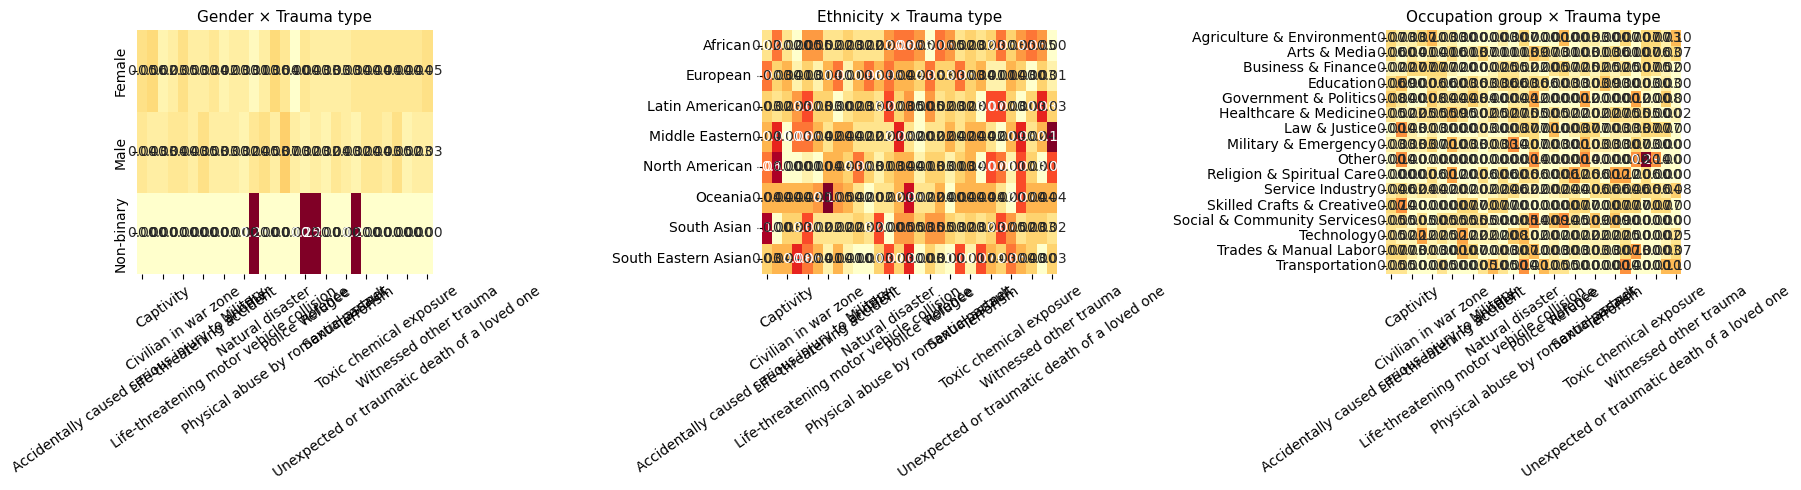

In [54]:
# ── Heatmaps for significant chi-square pairs ─────────────────────────────────
pairs = [
    ("gender",           "trauma_type",      "Gender × Trauma type"),
    ("ethnicity",        "trauma_type",      "Ethnicity × Trauma type"),
    ("occupation_group", "trauma_type",      "Occupation group × Trauma type"),
]

fig, axes = plt.subplots(1, len(pairs), figsize=(18, 5))
for ax, (v1, v2, title) in zip(axes, pairs):
    ct = pd.crosstab(df[v1], df[v2], normalize="index").round(2)
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, cbar=False)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig("persona_bias_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

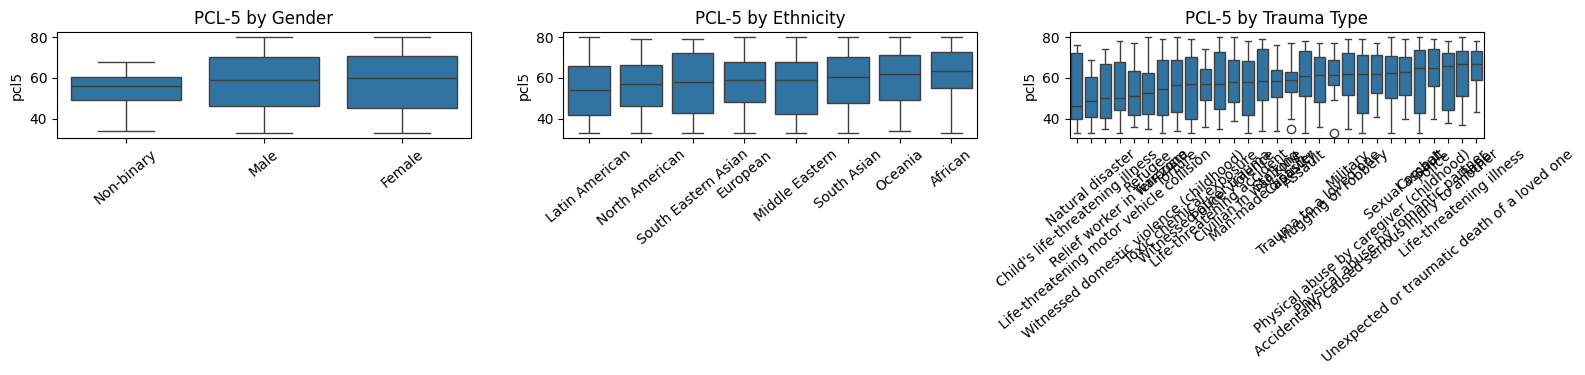

In [55]:
# ── PCL-5 distributions by group ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, var in zip(axes, ["gender", "ethnicity", "trauma_type"]):
    order = df.groupby(var)["pcl5"].median().sort_values().index.tolist()
    sns.boxplot(data=df, x=var, y="pcl5", order=order, ax=ax)
    ax.set_title(f"PCL-5 by {var.replace('_',' ').title()}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=40)

plt.suptitle("")
plt.tight_layout()
plt.savefig("pcl5_distributions.png", dpi=150, bbox_inches="tight")
plt.show()